# 4. Rispondere alle domande
Trasforma le seguenti richiesti in formule per estrarre infromazioni dal dataframe
- Mostrami le vendite maggiori di 10

- Mostrami i dati del 2018

- Mostrami le vendite maggiori di 13 e l'anno è il 2018

- Mostrami tutto TRANNE i casi in cui le vendite sono maggiori di 13 e l'anno è il 2018

- Mostrami i dati dove le vendite divise per 3 sono maggiori di 3

- Mostrami i dipendenti i cui nomi sono alfabeticamente dopo la J



In [2]:
import pandas as pd

sales = pd.DataFrame(
    data={
        "employee": [
            "Katrina",
            "Guanyu",
            "Jan",
            "Roman",
            "Jacqueline",
            "Paola",
            "Esperanza",
            "Alaina",
            "Egweyn",
        ],
        "sales": [14, 17, 6, 12, 8, 3, 7, 15, 5],
        "year": [2018, 2019, 2020, 2018, 2020, 2019, 2019, 2020, 2020],
    }
)
sales

,employee,sales,year
0,Katrina,14,2018
1,Guanyu,17,2019
2,Jan,6,2020
3,Roman,12,2018
4,Jacqueline,8,2020
5,Paola,3,2019
6,Esperanza,7,2019
7,Alaina,15,2020
8,Egweyn,5,2020


In [11]:
vendite_maggiori = sales[sales["sales"]>10]
print("Vendite maggiori di 10: ", vendite_maggiori)

dati_2018 = sales[sales["year"]==2018]
print("Dati del 2018: ", dati_2018)

vendite_magg_13_2018 = sales[(sales["year"]==2018) & (sales["sales"] >13)]
print("Vendite maggiori di 13 nell'anno 2018: ", vendite_magg_13_2018)

filtro_combinato = sales[(sales["year"]!=2018) & (sales["sales"]>13)]
print("Vendite tranne anno2018 e vendite maggiori a 13: ", filtro_combinato)

maggiore_tre = sales[(sales["sales"]/3) >3 ]
print("Vendite divise per tre che sono maggiori di tre: ", maggiore_tre)

nomi_dopo_j = sales[sales['employee'] > 'J']
print("Nomi di impiegati che iniziano dopo la lettera J: ",nomi_dopo_j)

Vendite maggiori di 10:    employee  sales  year
0  Katrina     14  2018
1   Guanyu     17  2019
3    Roman     12  2018
7   Alaina     15  2020
Dati del 2018:    employee  sales  year
0  Katrina     14  2018
3    Roman     12  2018
Vendite maggiori di 13 nell'anno 2018:    employee  sales  year
0  Katrina     14  2018
Vendite tranne anno2018 e vendite maggiori a 13:    employee  sales  year
1   Guanyu     17  2019
7   Alaina     15  2020
Vendite divise per tre che sono maggiori di tre:    employee  sales  year
0  Katrina     14  2018
1   Guanyu     17  2019
3    Roman     12  2018
7   Alaina     15  2020
Nomi di impiegati che iniziano dopo la lettera J:       employee  sales  year
0     Katrina     14  2018
2         Jan      6  2020
3       Roman     12  2018
4  Jacqueline      8  2020
5       Paola      3  2019


# 5. Analisi di un dataset di video giochi
1. Quanti videogiochi sono stati pubblicati
2. Quali sono i generi più popolari? Mostralo con un bar plot
3. Plotta l'evoluzione del numero di giochi pubblicati nel tempo
4. Prova a riprodurre questo plot 

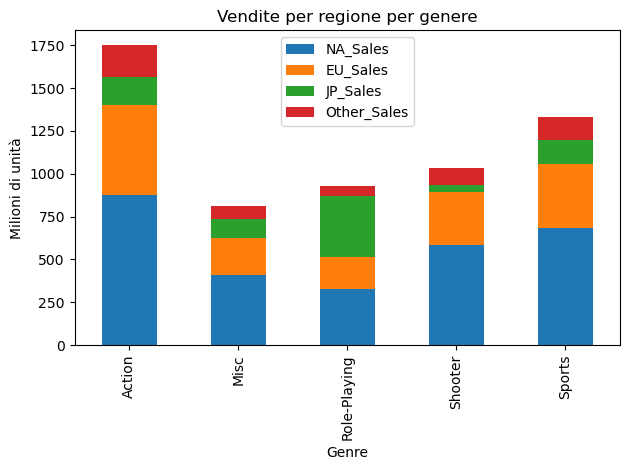


In [12]:
# Import dei pacchetti
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Caricamento del dataset
url = 'https://zenodo.org/record/5898311/files/vgsales.csv'
df = pd.read_csv(url)
df.head()

,Rank,Name,Platform,Year,Genre,Publisher,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales
0,1,Wii Sports,Wii,2006.0,Sports,Nintendo,41.49,29.02,3.77,8.46,82.74
1,2,Super Mario Bros.,NES,1985.0,Platform,Nintendo,29.08,3.58,6.81,0.77,40.24
2,3,Mario Kart Wii,Wii,2008.0,Racing,Nintendo,15.85,12.88,3.79,3.31,35.82
3,4,Wii Sports Resort,Wii,2009.0,Sports,Nintendo,15.75,11.01,3.28,2.96,33.00
4,5,Pokemon Red/Pokemon Blue,GB,1996.0,Role-Playing,Nintendo,11.27,8.89,10.22,1.00,31.37


Videogiochi pubblicati:  16598


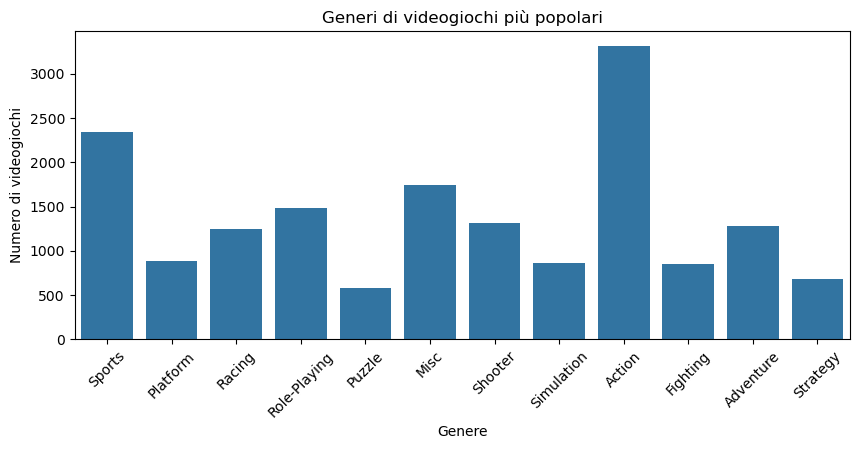

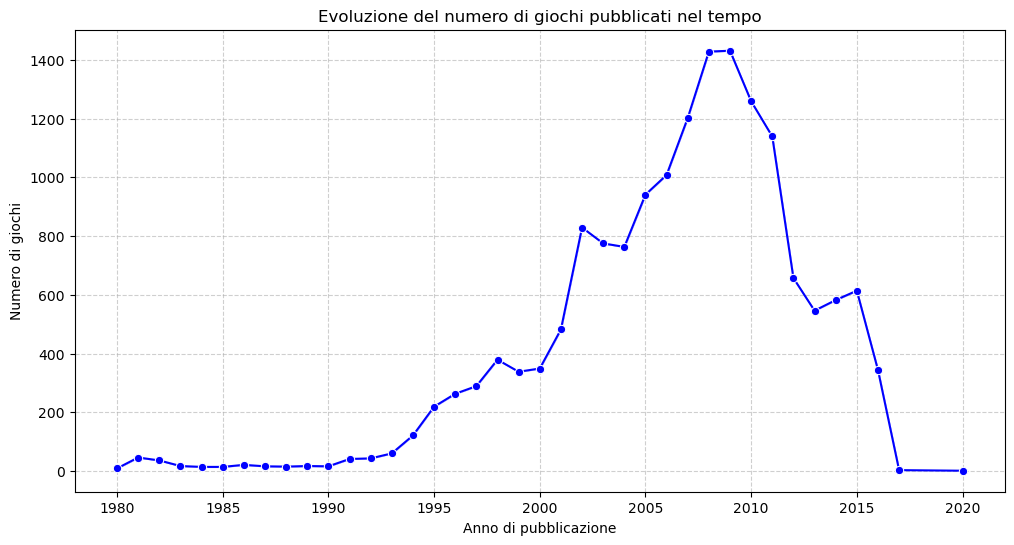

Text(0, 0.5, 'Milioni di unità')

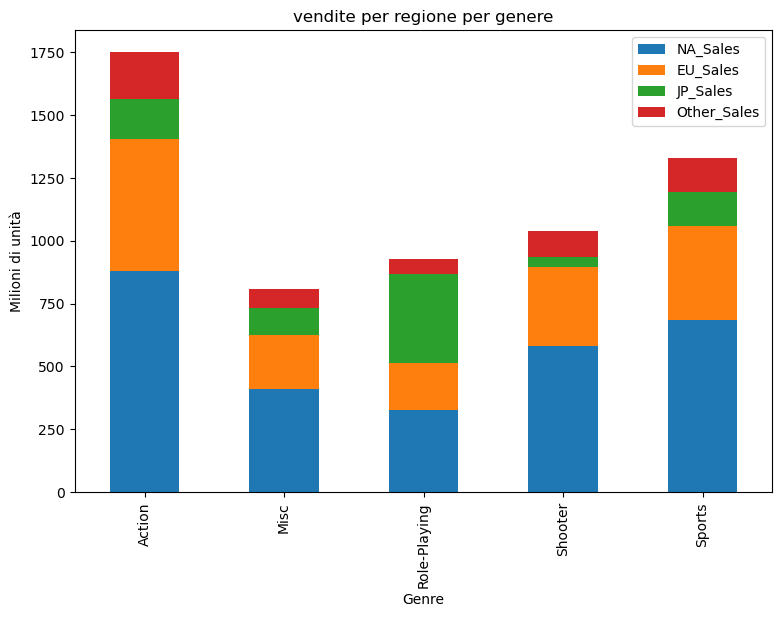

In [23]:
giochi_pubblicati = len(df)
print("Videogiochi pubblicati: ", giochi_pubblicati)

plt.figure(figsize=(10,4))
sns.countplot(data=df, x="Genre")
plt.title("Generi di videogiochi più popolari")
plt.xlabel("Genere")
plt.ylabel("Numero di videogiochi")
plt.xticks(rotation=45)
plt.show()

df_clean = df.dropna(subset=['Year']).copy()
df_clean['Year'] = df_clean['Year'].astype(int)
plt.figure(figsize=(12,6))
sns.lineplot(data=df_clean, x="Year", y="Rank", estimator="size", marker="o", color="b")
plt.title("Evoluzione del numero di giochi pubblicati nel tempo")
plt.xlabel("Anno di pubblicazione")
plt.ylabel("Numero di giochi")
plt.grid(True, linestyle="--", alpha=0.6)
plt.show()

generi_target = ['Action', 'Misc', 'Role-Playing', 'Shooter', 'Sports']
df_filtrato = df[df['Genre'].isin(generi_target)]
vendite_per_genere = df_filtrato.groupby('Genre')[['NA_Sales', 'EU_Sales', 'JP_Sales', 'Other_Sales']].sum()
vendite_per_genere.plot(kind="bar", stacked=True, figsize=(9,6))
plt.title("vendite per regione per genere")
plt.xlabel("Genre")
plt.ylabel("Milioni di unità")